# Contextualização

**Descrição do projeto**:

A Inteligência Artificial (IA) está revolucionando setores estratégicos da economia, desde serviços financeiros até saúde e marketing. Este projeto utiliza um dataset do Kaggle para investigar como a adoção de IA afeta indicadores-chave do mercado financeiro, como crescimento de receita e participação de mercado de empresas de IA, em comparação com outros setores (healthcare, automotive, media). 

Neste projeto, pretendemos: (1) analisar as ferramentas de IA mais utilizadas por setor, (2) verificar a qualidade dos dados, (3) explorar estatísticas descritivas e correlações, e (4) criar modelos de previsão para tendências futuras."

**Descrição do Dataset**:

O dataset explora a influência de conteúdo gerado por IA (Inteligência Artificial) em vários setores da indústria, incluindo jornalismo, redes sociais, entretenimento, marketing e *finanças*.


# Importando bibliotecas

In [37]:
# Imports de manipulação
import pandas as pd
import numpy as np

# Imports de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Imports de modelagem
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from math import sqrt

# Leitura e Limpeza dos dados

Não houve nenhuma alteração nos dados, não tem outliers e nem missing_values.
A baixo segue também a distribuição dos dados em gráficos para melhor visualização.
É muito interessante olhar a distribuição dos dados categóricos para ver um posível viez dos dados
Porém,  não acho que há algum viez. (anotação)

---

 ## Leitura da base de dados

In [38]:
#Leitura do arquivo
df = pd.read_csv('Global_AI_Content_Impact_Dataset.csv', sep = ',')
#Primeiras 20 linhas
df.head(n =20)

,Country,Year,Industry,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Top AI Tools Used,Regulation Status,Consumer Trust in AI (%),Market Share of AI Companies (%)
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41
5,USA,2021,Retail,66.95,47.72,0.86,27.58,64.42,ChatGPT,Lenient,68.14,8.09
6,Australia,2023,Media,68.23,6.14,6.20,53.13,53.16,Claude,Moderate,71.60,15.26
7,UK,2023,Gaming,91.27,33.87,41.67,56.26,59.93,ChatGPT,Moderate,46.98,28.51
8,Canada,2025,Education,17.02,87.77,4.59,52.45,64.72,Claude,Moderate,60.55,22.70
9,China,2025,Healthcare,25.50,18.74,15.07,40.81,64.86,Stable Diffusion,Moderate,51.07,39.97


In [39]:
#Avaliando se há variáveis nulas e o tipo de variável de cada coluna
df.info()
#quantidade de linhas e colunas
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country                                     200 non-null    object 
 1   Year                                        200 non-null    int64  
 2   Industry                                    200 non-null    object 
 3   AI Adoption Rate (%)                        200 non-null    float64
 4   AI-Generated Content Volume (TBs per year)  200 non-null    float64
 5   Job Loss Due to AI (%)                      200 non-null    float64
 6   Revenue Increase Due to AI (%)              200 non-null    float64
 7   Human-AI Collaboration Rate (%)             200 non-null    float64
 8   Top AI Tools Used                           200 non-null    object 
 9   Regulation Status                           200 non-null    object 
 10  Consumer Trust

(200, 12)

Não há missing values

## Quantidade de aparições das variáveis categóricas e Years

Importante ver a quantidade de aparições para análisar um possível inviesamento dos dados ou uma possível tendência

In [40]:
# Colunas categóricas e número de aparições de cada variável
categorical_cols = ['Country','Year', 'Industry', 'Top AI Tools Used', 'Regulation Status']
categorical_counts = {}

# Criando os dicionários de contagem para cada coluna categórica
for col in categorical_cols:
    categorical_counts[col] = df[col].value_counts().to_dict()
    print(f"Contagem de valores para a coluna '{col}':")
    print(categorical_counts[col])
    print("-" * 30)

Contagem de valores para a coluna 'Country':
{'France': 24, 'India': 24, 'Japan': 22, 'China': 21, 'USA': 21, 'South Korea': 20, 'UK': 20, 'Germany': 17, 'Canada': 16, 'Australia': 15}
------------------------------
Contagem de valores para a coluna 'Year':
{2020: 47, 2025: 38, 2021: 32, 2022: 31, 2023: 29, 2024: 23}
------------------------------
Contagem de valores para a coluna 'Industry':
{'Media': 31, 'Gaming': 27, 'Retail': 21, 'Automotive': 19, 'Marketing': 19, 'Manufacturing': 18, 'Legal': 17, 'Education': 17, 'Healthcare': 17, 'Finance': 14}
------------------------------
Contagem de valores para a coluna 'Top AI Tools Used':
{'Midjourney': 37, 'Claude': 31, 'ChatGPT': 31, 'Stable Diffusion': 27, 'DALL-E': 26, 'Bard': 24, 'Synthesia': 24}
------------------------------
Contagem de valores para a coluna 'Regulation Status':
{'Moderate': 76, 'Lenient': 63, 'Strict': 61}
------------------------------


Acho interessante pensar porque há mais aparições de 2020 do que dos anos até 2025 nos dados, dado que parece ser um concensso que a AI começou a ser mais usada pós 2020 ou/e pensar pq tem mais dados de Media e Gaming. (anotação)

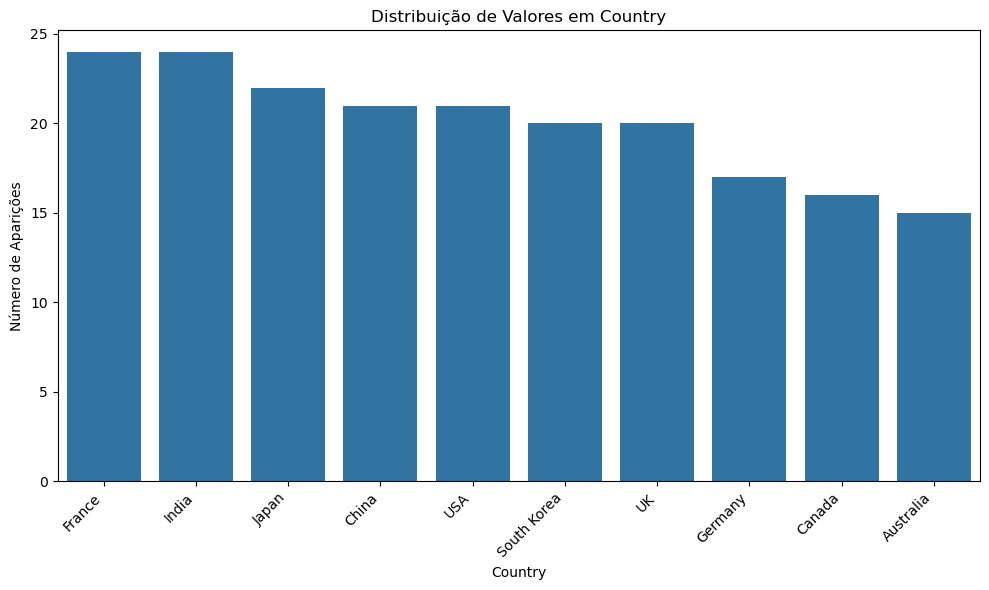

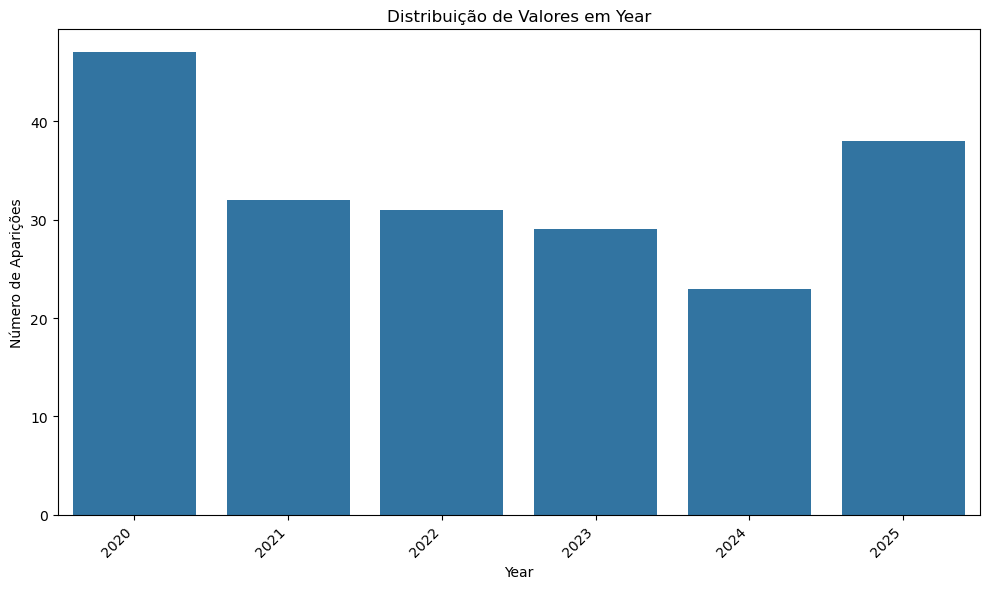

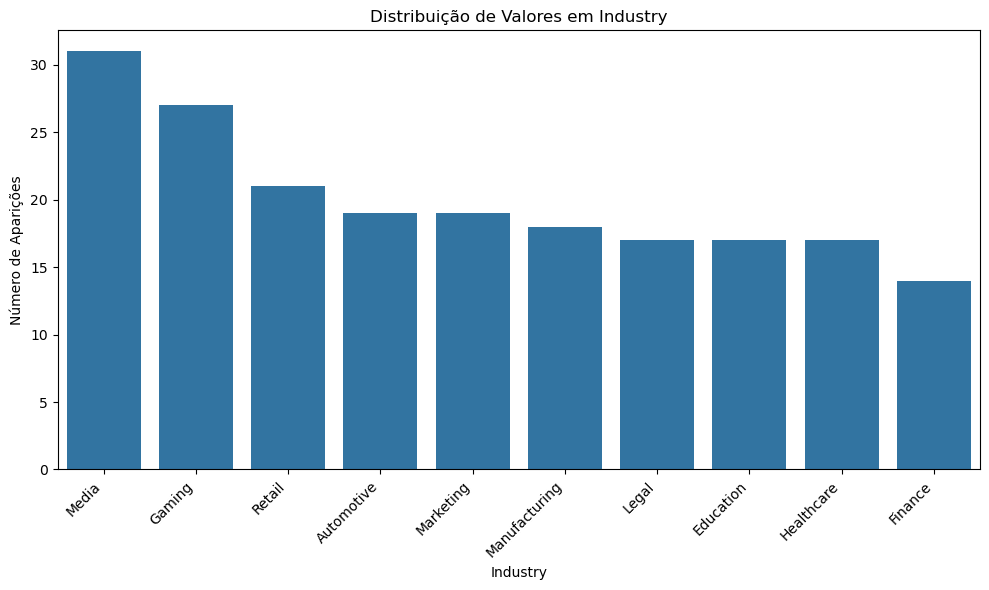

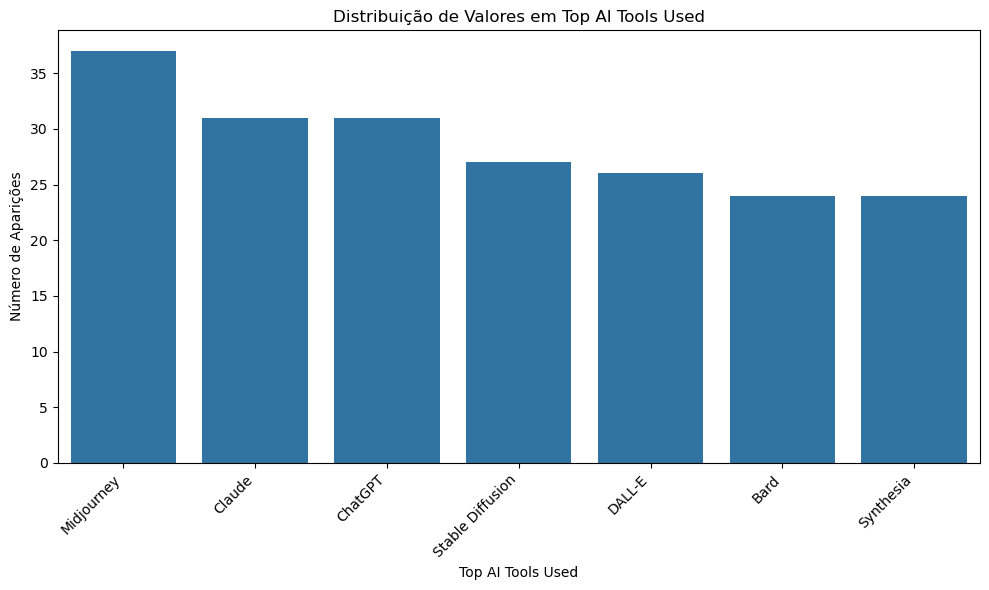

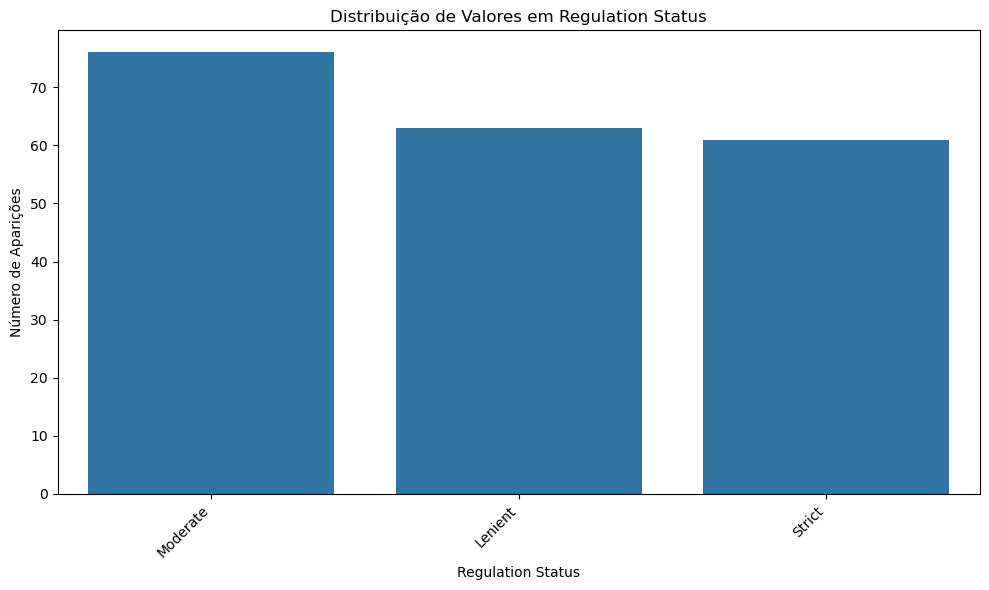

In [41]:
# Gerando os gráficos de barras das aparições
for col, counts in categorical_counts.items():
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts.keys()), y=list(counts.values()))
    plt.title(f'Distribuição de Valores em {col}')
    plt.xlabel(col)
    plt.ylabel('Número de Aparições')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Quartis e Boxplot (Variáveis quantitativas)

Spoiler: não há outliers

In [42]:
quantitative_cols = ['AI Adoption Rate (%)', 'AI-Generated Content Volume (TBs per year)',
                     'Job Loss Due to AI (%)', 'Revenue Increase Due to AI (%)',
                     'Human-AI Collaboration Rate (%)', 'Consumer Trust in AI (%)',
                     'Market Share of AI Companies (%)']
quartiles = {}

# Calculando os quartis para cada coluna quantitativa
for col in quantitative_cols:
    quartiles[col] = df[col].quantile([0.25, 0.50, 0.75]).to_dict()
    print(f"Quartis para a coluna '{col}':")
    print(quartiles[col])
    print("-" * 30)

Quartis para a coluna 'AI Adoption Rate (%)':
{0.25: 33.2225, 0.5: 53.31, 0.75: 76.22}
------------------------------
Quartis para a coluna 'AI-Generated Content Volume (TBs per year)':
{0.25: 20.3225, 0.5: 44.32, 0.75: 71.62}
------------------------------
Quartis para a coluna 'Job Loss Due to AI (%)':
{0.25: 14.995000000000001, 0.5: 25.735, 0.75: 37.417500000000004}
------------------------------
Quartis para a coluna 'Revenue Increase Due to AI (%)':
{0.25: 17.9075, 0.5: 42.1, 0.75: 58.697500000000005}
------------------------------
Quartis para a coluna 'Human-AI Collaboration Rate (%)':
{0.25: 37.77, 0.5: 54.515, 0.75: 69.4025}
------------------------------
Quartis para a coluna 'Consumer Trust in AI (%)':
{0.25: 44.755, 0.5: 59.215, 0.75: 74.88499999999999}
------------------------------
Quartis para a coluna 'Market Share of AI Companies (%)':
{0.25: 14.0525, 0.5: 27.39, 0.75: 38.432500000000005}
------------------------------


In [43]:
#Contagem de outliers
outlier_counts = {}

for col in quantitative_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)
    print(f"A coluna '{col}' tem {outlier_counts[col]} outlier(s).")

print("\nContagem total de outliers por coluna:")
print(outlier_counts)

A coluna 'AI Adoption Rate (%)' tem 0 outlier(s).
A coluna 'AI-Generated Content Volume (TBs per year)' tem 0 outlier(s).
A coluna 'Job Loss Due to AI (%)' tem 0 outlier(s).
A coluna 'Revenue Increase Due to AI (%)' tem 0 outlier(s).
A coluna 'Human-AI Collaboration Rate (%)' tem 0 outlier(s).
A coluna 'Consumer Trust in AI (%)' tem 0 outlier(s).
A coluna 'Market Share of AI Companies (%)' tem 0 outlier(s).

Contagem total de outliers por coluna:
{'AI Adoption Rate (%)': 0, 'AI-Generated Content Volume (TBs per year)': 0, 'Job Loss Due to AI (%)': 0, 'Revenue Increase Due to AI (%)': 0, 'Human-AI Collaboration Rate (%)': 0, 'Consumer Trust in AI (%)': 0, 'Market Share of AI Companies (%)': 0}


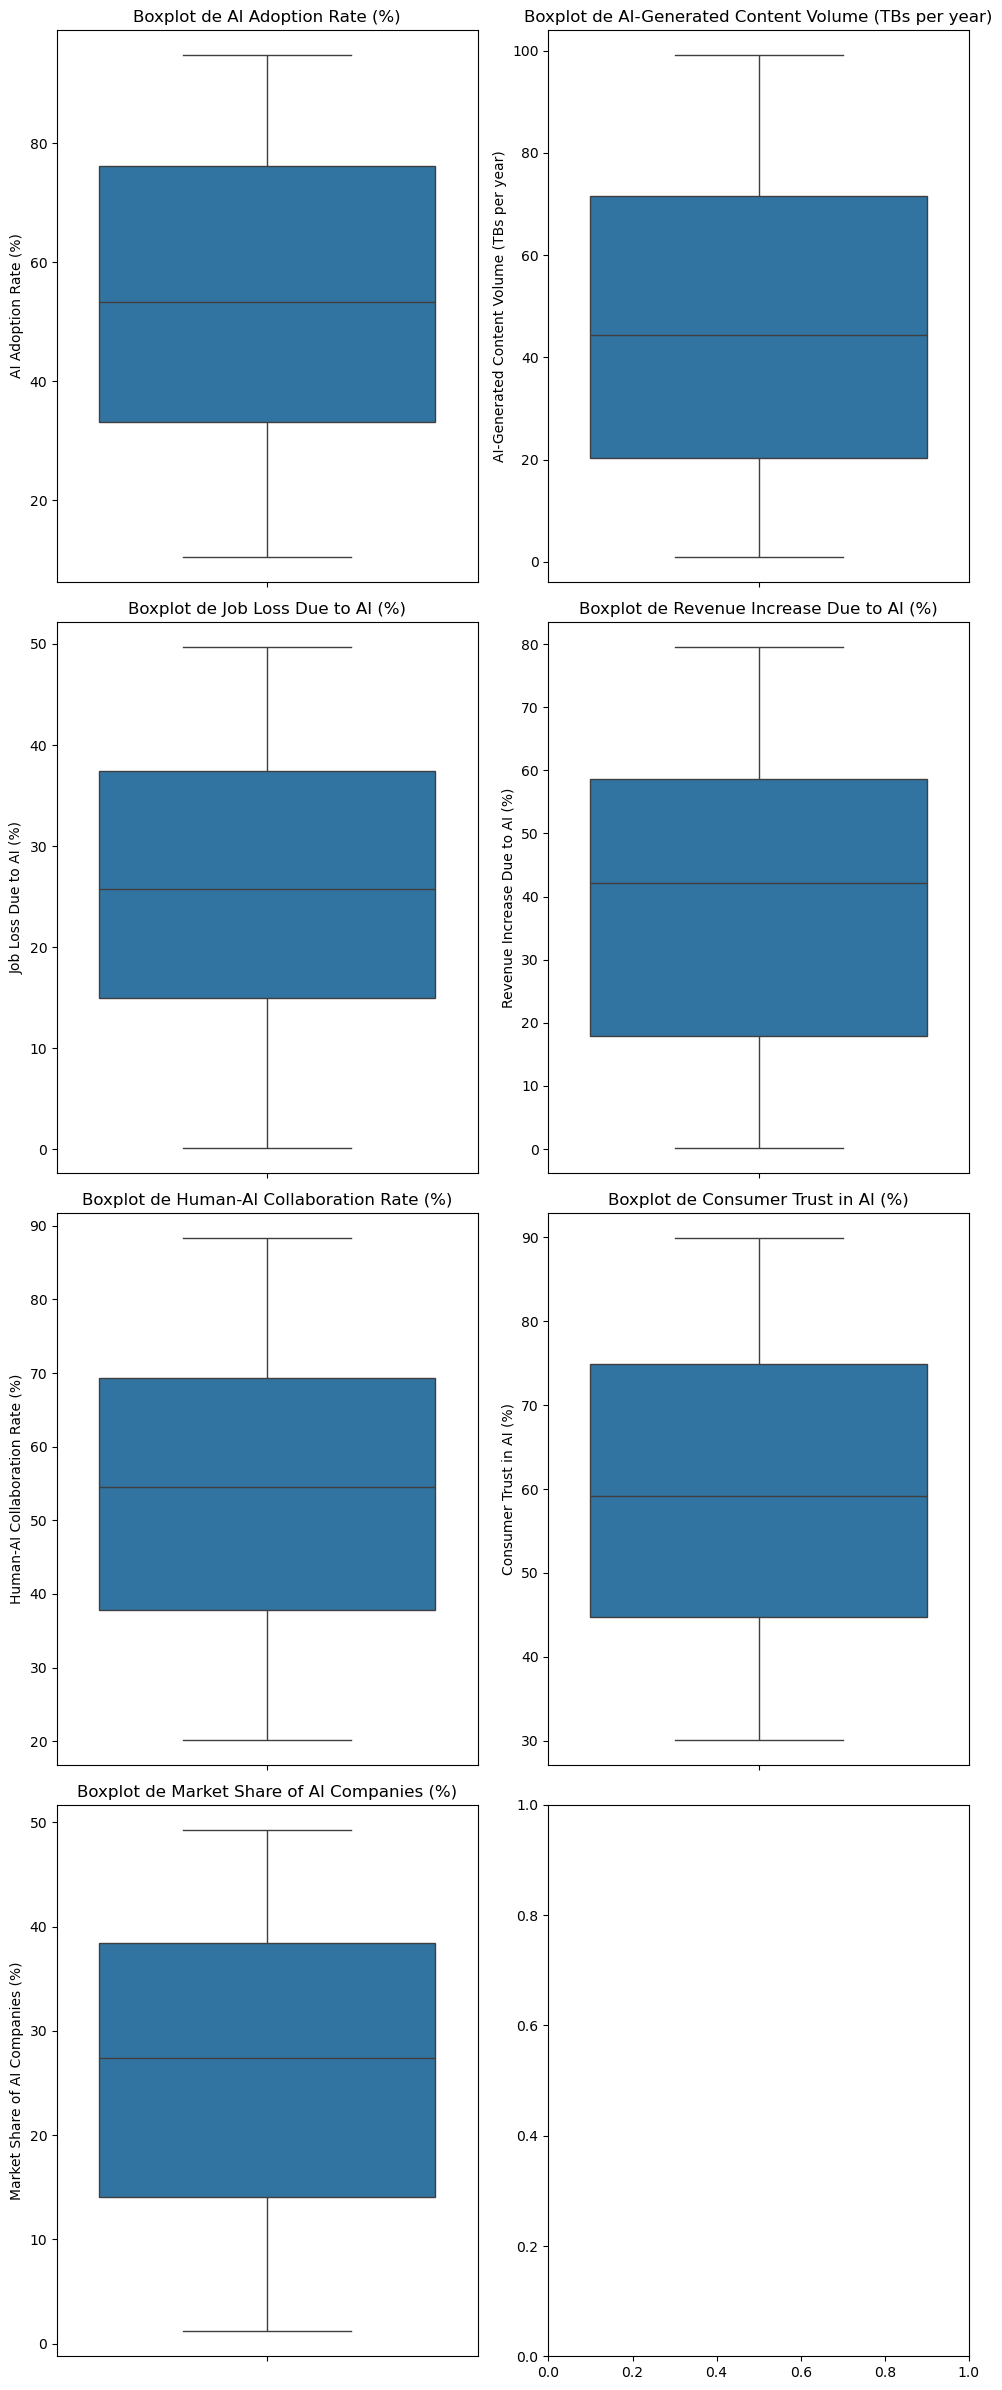

In [44]:
num_cols = len(quantitative_cols)
num_rows = (num_cols + 1) // 2  # Calcula o número de linhas necessárias

fig, axes = plt.subplots(num_rows, 2, figsize=(10, 6 * num_rows))
axes = axes.flatten()  # Transforma a matriz de eixos em um array plano para facilitar a indexação

for i, col in enumerate(quantitative_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# Estatísticas descritivas

Geramos e analisamos estatísticas descritivas gerais da base de dados

In [45]:
df.describe()

,Year,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Consumer Trust in AI (%),Market Share of AI Companies (%)
count,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2022.315000,54.265850,46.07260,25.788250,39.719450,54.102150,59.425150,26.569550
std,1.825496,24.218067,29.16122,13.901105,23.829545,19.247079,17.319668,14.023729
min,2020.000000,10.530000,1.04000,0.090000,0.140000,20.210000,30.120000,1.180000
25%,2021.000000,33.222500,20.32250,14.995000,17.907500,37.770000,44.755000,14.052500
50%,2022.000000,53.310000,44.32000,25.735000,42.100000,54.515000,59.215000,27.390000
75%,2024.000000,76.220000,71.62000,37.417500,58.697500,69.402500,74.885000,38.432500
max,2025.000000,94.760000,99.06000,49.710000,79.550000,88.290000,89.880000,49.280000


Também parace proveitoso gerar estatísticas descritivas por país, para ver eventuais diferenças das variáveis por essa categoria

In [46]:
estatisticas = ["mean", "std"]
agg_dict = {col: estatisticas for col in quantitative_cols}
agg_dict["Year"] = "median"
df.groupby("Country").agg(agg_dict).round(2)

AI Adoption Rate (%)         \
                            mean    std   
Country                                   
Australia                  56.08  26.16   
Canada                     52.19  23.47   
China                      52.89  25.38   
France                     56.52  23.69   
Germany                    51.46  27.43   
India                      51.81  20.12   
Japan                      54.21  25.47   
South Korea                50.56  24.36   
UK                         64.69  24.83   
USA                        52.08  24.50   

            AI-Generated Content Volume (TBs per year)         \
                                                  mean    std   
Country                                                         
Australia                                        48.77  30.25   
Canada                                           49.11  32.00   
China                                            52.83  29.02   
France                                           47.43  28.73   
Germany                                          44.79  26.83   
India                                            45.00  29.69   
Japan                                            40.25  31.34   
South Korea                                      48.69  29.86   
UK                                               39.09  28.15   
USA                                              46.05  29.69   

            Job Loss Due to AI (%)        Revenue Increase Due to AI (%)  \
                              mean    std                           mean   
Country                                                                    
Australia                    18.82  13.74                          49.70   
Canada                       30.99  13.47                          38.75   
China                        29.09  13.42                          42.60   
France                       26.48  13.86                          39.55   
Germany                      28.10  14.35                          40.58   
India                        25.23  15.94                          40.08   
Japan                        25.51  12.78                          34.61   
South Korea                  25.54  11.31                          34.25   
UK                           27.13  14.21                          36.12   
USA                          20.71  14.41                          43.52   

                   Human-AI Collaboration Rate (%)         \
               std                            mean    std   
Country                                                     
Australia    23.73                           59.48  19.37   
Canada       24.01                           55.20  16.03   
China        27.45                           54.51  17.12   
France       24.09                           52.76  20.83   
Germany      27.16                           49.63  20.21   
India        22.33                           54.20  21.47   
Japan        17.76                           42.38  19.37   
South Korea  24.24                           59.47  20.10   
UK           26.33                           58.27  14.19   
USA          22.81                           57.26  19.05   

            Consumer Trust in AI (%)        Market Share of AI Companies (%)  \
                                mean    std                             mean   
Country                                                                        
Australia                      63.58  13.73                            23.69   
Canada                         62.15  17.55                            28.28   
China                          60.32  17.56                            27.06   
France                         58.44  16.56                            27.19   
Germany                        64.95  16.57                            30.46   
India                          59.92  16.85                            28.34   
Japan                          61.00  20.54                            27.15   
South Korea            

Gerando estatísticas por setor:

In [47]:
agg_dict = {col: ["mean"] for col in quantitative_cols}
agg_dict["Year"] = "median"
df.groupby("Industry").agg(agg_dict)

,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Consumer Trust in AI (%),Market Share of AI Companies (%),Year
,mean,mean,mean,mean,mean,mean,mean,median
Industry,,,,,,,,
Automotive,54.887895,43.159474,28.916842,46.482632,55.906316,61.240000,29.591579,2022.0
Education,57.028235,60.822941,26.142353,39.543529,58.875882,51.650000,22.835882,2021.0
Finance,55.764286,37.545000,27.790000,36.257143,53.609286,56.180714,28.995714,2022.0
Gaming,60.416296,44.470370,27.204074,33.234444,53.096296,61.342963,24.058148,2023.0
Healthcare,55.734118,46.971765,25.579412,38.586471,55.227059,60.160588,29.642941,2023.0
Legal,56.077647,59.902941,28.234118,41.824118,50.743529,57.789412,20.238824,2023.0
Manufacturing,57.014444,49.809444,32.746111,42.807222,55.966667,58.272778,25.964444,2021.0
Marketing,54.244211,37.197368,19.577895,36.813684,55.324211,58.671579,28.681579,2023.0


Gerando estatísticas por ano:

In [48]:
estatisticas = ["mean", "std"]
agg_dict = {col: estatisticas for col in quantitative_cols}
df.groupby("Year").agg(agg_dict).round(2)

AI Adoption Rate (%)        AI-Generated Content Volume (TBs per year)  \
                     mean    std                                       mean   
Year                                                                          
2020                50.99  24.33                                      41.83   
2021                57.57  22.95                                      53.78   
2022                52.99  24.18                                      46.82   
2023                59.68  26.04                                      37.69   
2024                51.26  24.35                                      52.60   
2025                54.26  24.17                                      46.67   

            Job Loss Due to AI (%)        Revenue Increase Due to AI (%)  \
        std                   mean    std                           mean   
Year                                                                       
2020  26.78                  28.17  12.87                          44.20   
2021  27.54                  28.23  14.56                          42.99   
2022  30.42                  22.82  13.11                          35.48   
2023  28.05                  24.45  13.43                          33.03   
2024  30.68                  26.28  17.39                          42.45   
2025  31.38                  23.92  13.24                          38.33   

            Human-AI Collaboration Rate (%)        Consumer Trust in AI (%)  \
        std                            mean    std                     mean   
Year                                                                          
2020  20.51                           54.12  19.30                    59.21   
2021  24.82                           53.15  21.67                    59.87   
2022  25.15                           48.78  17.74                    59.44   
2023  24.10                           57.13  14.68                    62.29   
2024  24.96                           52.99  21.70                    58.07   
2025  24.50                           57.59  19.82                    57.94   

            Market Share of AI Companies (%)         
        std                             mean    std  
Year                                                 
2020  17.00                            24.55  14.37  
2021  16.36                            27.33  15.38  
2022  18.90                            26.57  11.60  
2023  18.20                            27.65  13.23  
2024  19.19                            29.70  15.81  
2025  16.14                            25.72  14.10

# Correlações

Ao avaliar as relações entre as variáveis, notamos que de forma agregada parece não haver relação, mas quando dividimos por país/setor obtemos relações que podem ser exploradas

Primeiro plotamos as variáveis numéricas entre si

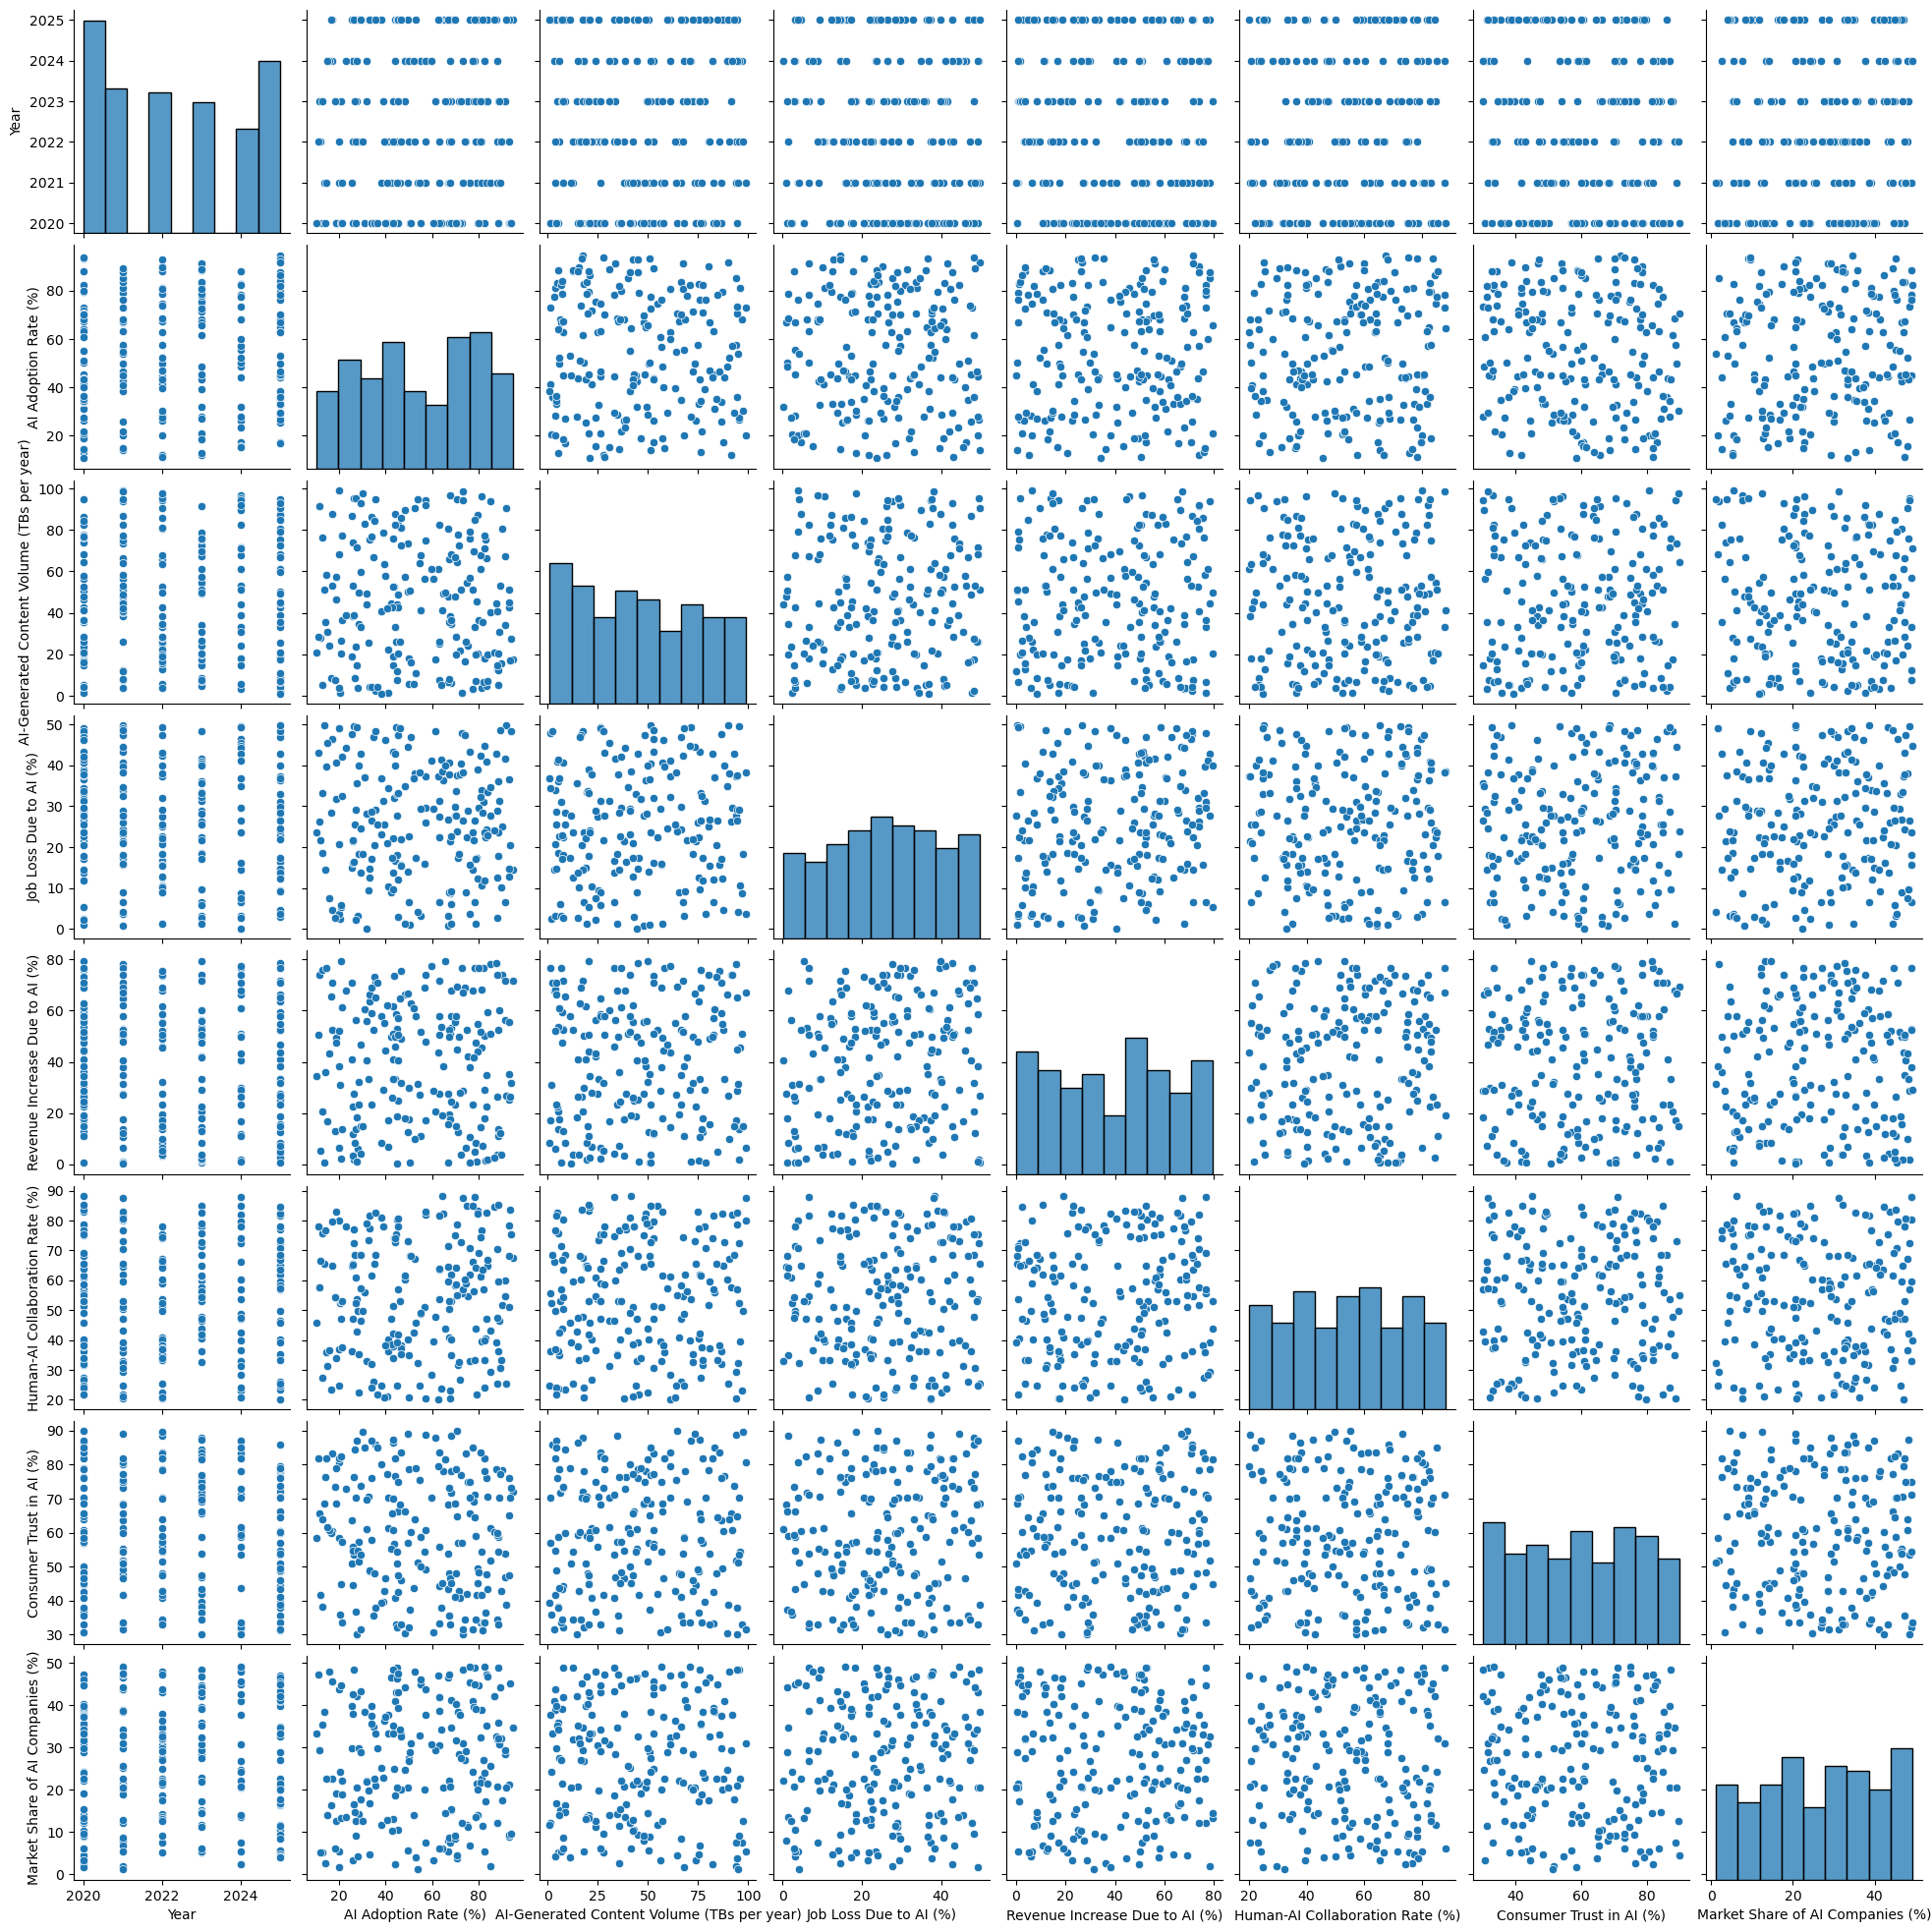

In [49]:
sns.pairplot(data=df)

plt.show()

A distribuição dos pontos nos gráficos de dispersão aparentam indicar pouca ou nenhuma correlação entre as variáveis.

Elaborando uma matriz de correlação, essa ausência de relações é reforçada:

In [50]:
# Cálculo das correlações

newdf = df.drop('Year', axis='columns')
print(newdf.select_dtypes(include=['number']).corr())


                                            AI Adoption Rate (%)  \
AI Adoption Rate (%)                                    1.000000   
AI-Generated Content Volume (TBs per year)             -0.042364   
Job Loss Due to AI (%)                                 -0.004589   
Revenue Increase Due to AI (%)                          0.001883   
Human-AI Collaboration Rate (%)                         0.050359   
Consumer Trust in AI (%)                               -0.115227   
Market Share of AI Companies (%)                        0.065829   

                                            AI-Generated Content Volume (TBs per year)  \
AI Adoption Rate (%)                                                         -0.042364   
AI-Generated Content Volume (TBs per year)                                    1.000000   
Job Loss Due to AI (%)                                                        0.062185   
Revenue Increase Due to AI (%)                                                0.029310   
Human

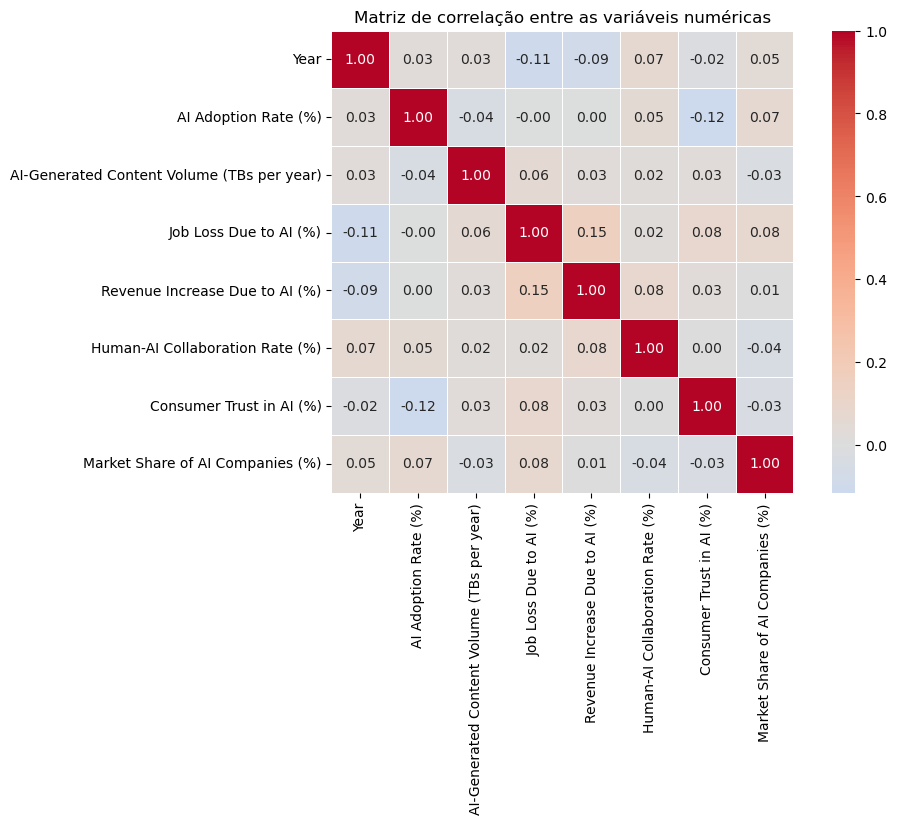

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))

# Selecionando apenas variáveis numéricas
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr,                  # Matriz de correlação
            annot=True,            # Mostrar valores dentro dos quadrados
            fmt=".2f",             # Formatar casas decimais
            cmap="coolwarm",       # Mapa de cores 
            center=0,              # Centralizar o mapa em 0 
            linewidths=0.5,        # Espessura das linhas entre células
            square=True,           # Manter células quadradas
            ax=ax
)

plt.title("Matriz de correlação entre as variáveis numéricas")
plt.show()

As variáveis não aparentam ter relação entre si, com a maior correlação positiva (15%) sendo entre Revenue Increade Due to AI e Job Loss Due to AI; e a maior negativa (12%) sendo entre Consumer Trust in AI e AI Adoption Rate.

Há uma outra consideração a ser feita, tecnologias de IA podem impactar de forma diferente os diversos setores ou países onde é inserida.

A função abaixo realiza um plot da matriz de correlação por valor de uma categoria.

In [52]:
def plot_corr_category(df, category, num_cols=1):
    
    # parametriza o numero de linhas dado o número de colunas
    num_rows=int(np.ceil(df[category].nunique()//num_cols))

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 6 * num_rows))
    axes = axes.flatten()
    
    cat_values = df[category].unique()
    
    # Plota a matriz de correlação para cada valor da categoria
    for i in range(len(cat_values)):    
        mask = df[category]==cat_values[i]
        corr = df[mask].select_dtypes(include='number').corr()


        sns.heatmap(corr,                  # Matriz de correlação
            annot=True,            # Mostrar valores dentro dos quadrados
            fmt=".2f",             # Formatar casas decimais
            cmap="coolwarm",       # Mapa de cores 
            center=0,              # Centralizar o mapa em 0 
            linewidths=0.5,        # Espessura das linhas entre células
            square=True,           # Manter células quadradas
            ax=axes[i]
        )

        axes[i].set_title(f'Matriz de correlação de {cat_values[i]}')
        axes[i].set_xticklabels(axes[i].get_xticklabels(),rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

O objetivo desses plots não é extrair diretamente alguma relação, mas mostrar que existem correlações entre os dados e que é importante levar em consideração as categorias as quais os dados pertencem.

Aplicando a função por país:

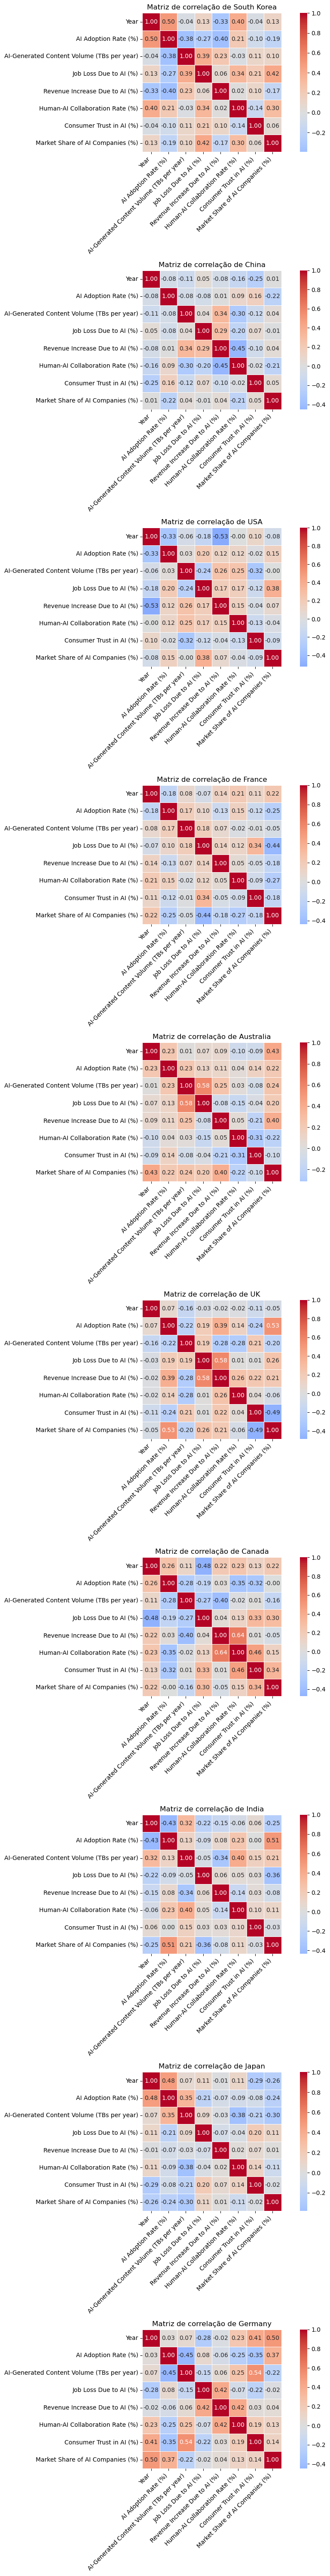

In [53]:
plot_corr_category(df,"Country")

Aplicando a função por setor de atuação:

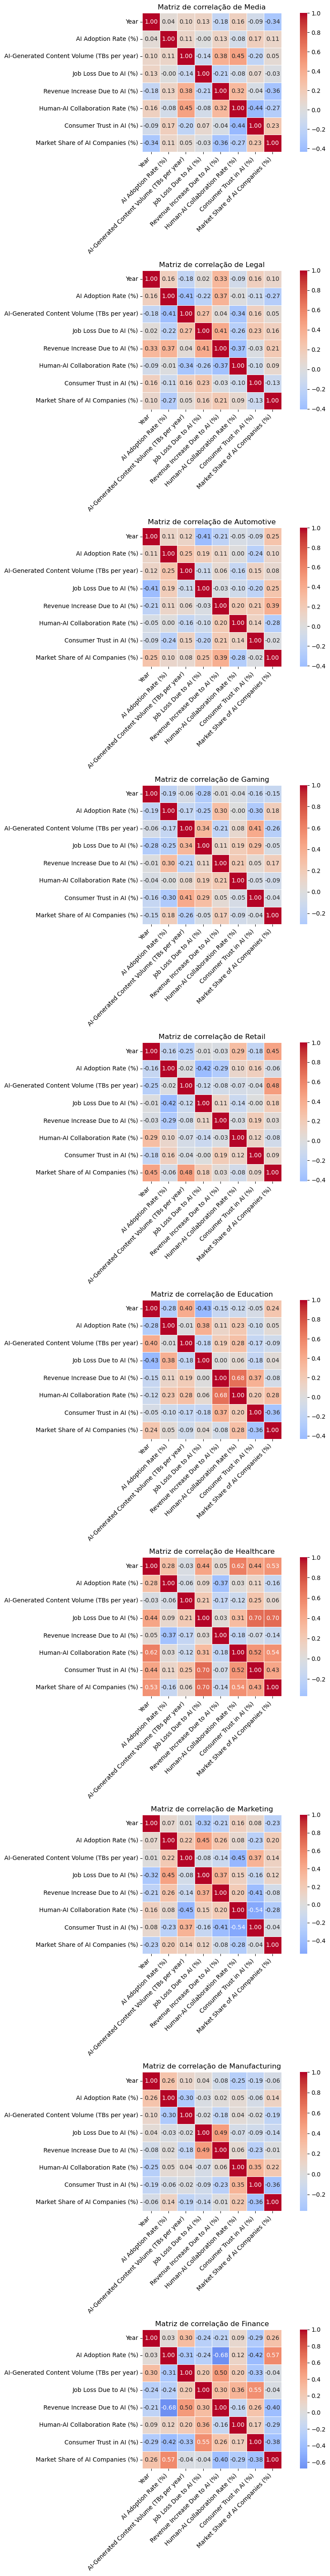

In [54]:
plot_corr_category(df,"Industry")

Por exemplo, a relação entre a taxa de adoção de IA e o aumento de receita é positivamente correlacionado (indicando retornos crescentes) nos setores de Marketing e Gaming, mas negativamente correlacionado (indicando retornos decrescentes) nos setores de Saúde e Finanças.

A relação média é mostrada no gráfico abaixo:

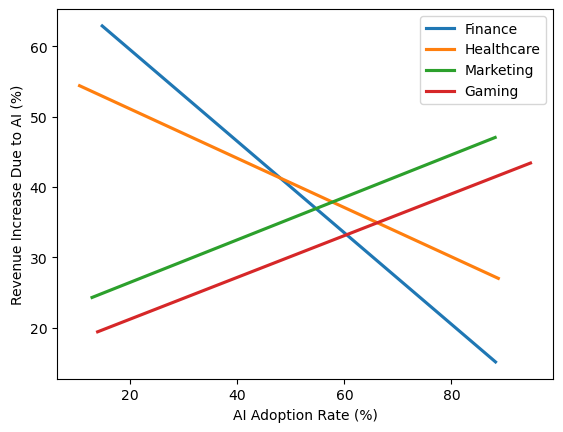

In [55]:
for industry in ["Finance", "Healthcare", "Marketing", "Gaming"]:
    sns.regplot(x="AI Adoption Rate (%)",
                y="Revenue Increase Due to AI (%)",
                data=df[df["Industry"]==industry],
                ci=None,
                label=industry,
                scatter=False)

plt.legend()
plt.show()

Em termos de regulação, parece que regulações moderadas e duras levam a relações diferente entre as variáveis em comparação com uma regulação mais leniente:

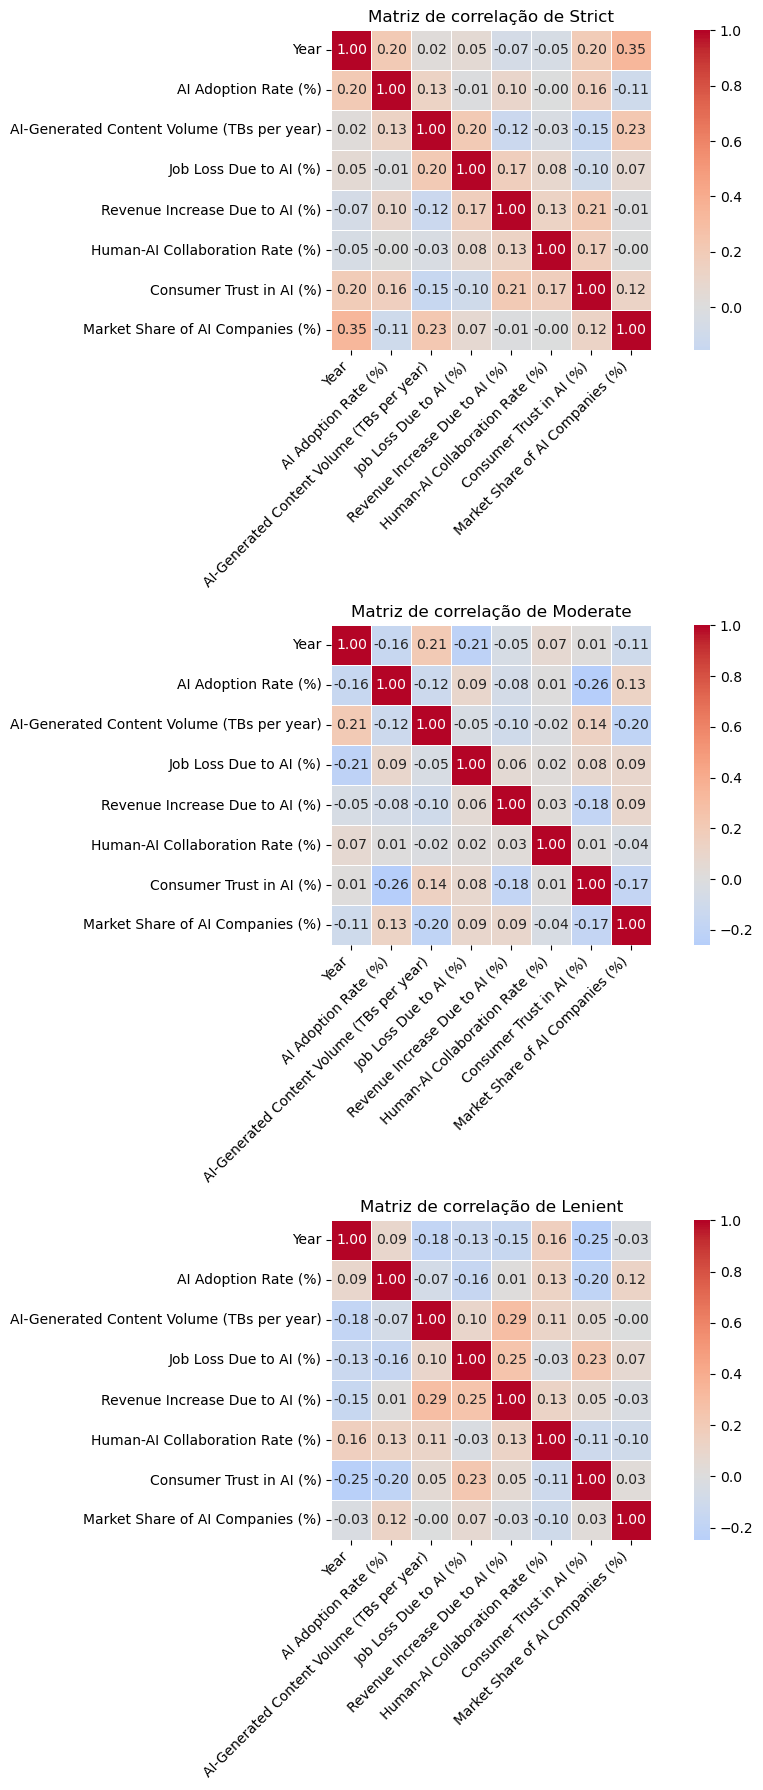

In [56]:
plot_corr_category(df,"Regulation Status")

Comparando alguns dados de interesse (aumento de receita, confiança do consumidor e perda de empregos) por regulação:

<Axes: ylabel='Revenue Increase Due to AI (%)'>

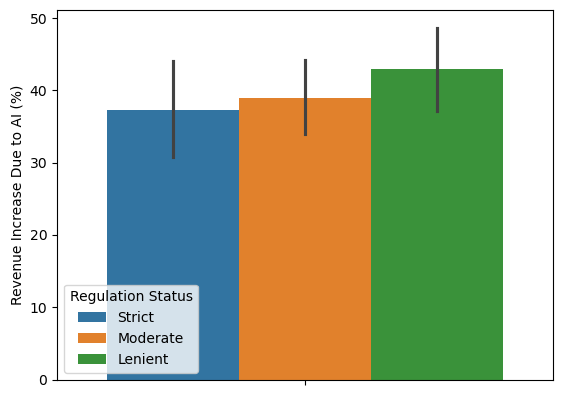

In [57]:
sns.barplot(y= "Revenue Increase Due to AI (%)",
            hue="Regulation Status",
            data=df)

<Axes: ylabel='Job Loss Due to AI (%)'>

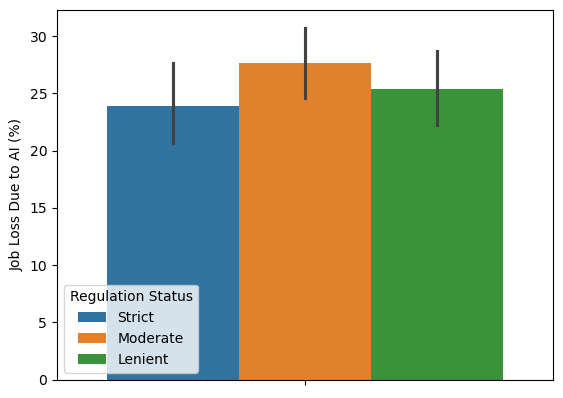

In [58]:
sns.barplot(y= "Job Loss Due to AI (%)",
            hue="Regulation Status",
            data=df)

<Axes: ylabel='Consumer Trust in AI (%)'>

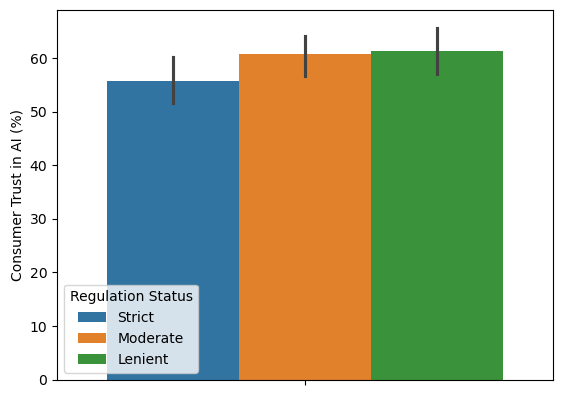

In [59]:
sns.barplot(y= "Consumer Trust in AI (%)",
            hue="Regulation Status",
            data=df)

## Verificando os setores da indústria que mais utilizam IA

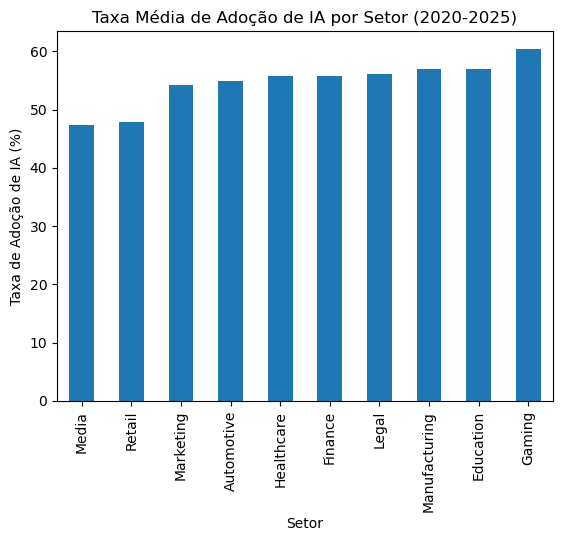

In [60]:
# Ordenando os valores de forma decrescente
sorted_df = df.groupby('Industry')['AI Adoption Rate (%)'].mean().sort_values(ascending=True)

# Gráfico de barras
sorted_df.plot(kind='bar')
plt.title('Taxa Média de Adoção de IA por Setor (2020-2025)')
plt.xlabel('Setor')
plt.ylabel("Taxa de Adoção de IA (%)")
plt.show()

Como é possível observar, o setor que mais utiliza IA é o de *Gaming*, seguido por *Education*, *Manufacturing*, *Legal* e *Finance*

### Os setores da indústria que mais geram conteúdo de IA

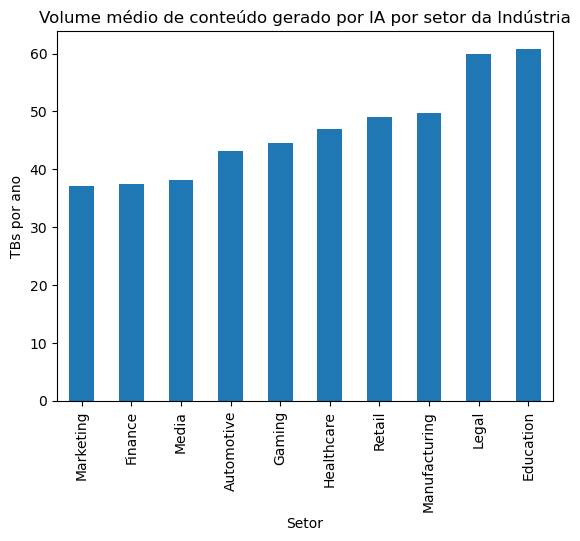

In [61]:
# Ordenando os valores de forma decrescente
df_1 = df.groupby('Industry')['AI-Generated Content Volume (TBs per year)'].mean().sort_values(ascending=True)

# Gráfico de barras
df_1.plot(kind='bar')
plt.title('Volume médio de conteúdo gerado por IA por setor da Indústria')
plt.ylabel('TBs por ano')
plt.xlabel('Setor')
plt.show()


O setor com maior volume médio de conteúdo gerado por IA é *Education*, seguido por *Legal*, *Manufacturing*, *Retail* e *Healthcare*. 

Vale apontar que, apesar de *Finance* ser o 5o setor que mais utiliza IA, é o 2o que menos produz conteúdo gerado por IA.

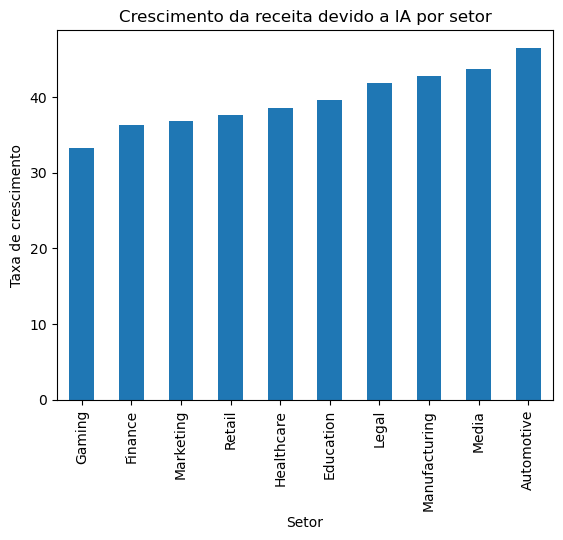

In [62]:
# Ordenando os valores de forma decrescente
df_2 = df.groupby('Industry')['Revenue Increase Due to AI (%)'].mean().sort_values(ascending=True)

# Gráfico de barras
df_2.plot(kind='bar')
plt.title('Crescimento da receita devido a IA por setor')
plt.ylabel('Taxa de crescimento')
plt.xlabel('Setor')
plt.show()

O setor com maior crescimento médio de receita devido a IA é *Automotive*, seguido por *Media*, *Manufacturing*, *Legal* e *Education*. 

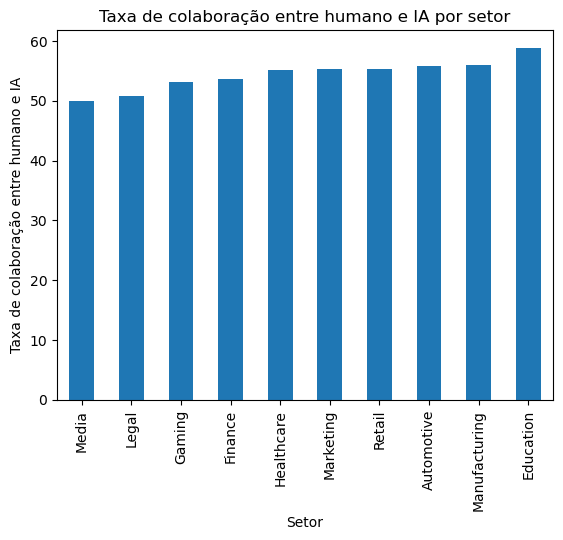

In [63]:
# Ordenando os valores de forma decrescente
df_3 = df.groupby('Industry')['Human-AI Collaboration Rate (%)'].mean().sort_values(ascending=True)

# Gráfico de barras
df_3.plot(kind='bar')
plt.title('Taxa de colaboração entre humano e IA por setor')
plt.ylabel('Taxa de colaboração entre humano e IA')
plt.xlabel('Setor')
plt.show()

O setor com maior taxa de colaboração média entre humano e IA é *Education*, seguido por *Manufacturing*, *Automotive*, *Retail* e *Marketing*. 

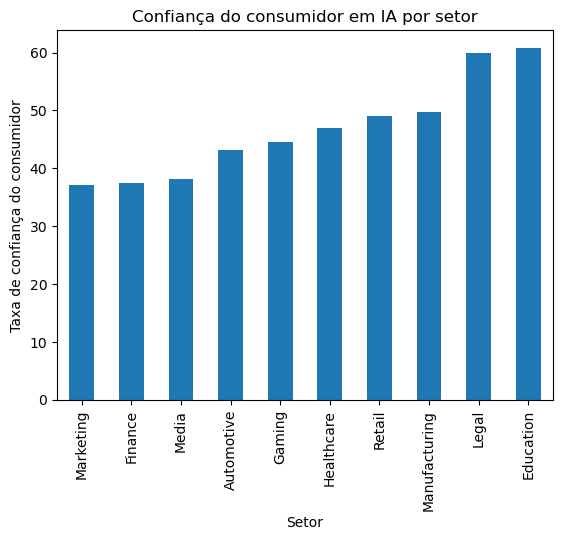

In [64]:
# Ordenando os valores de forma decrescente
df_4 = df.groupby('Industry')['Consumer Trust in AI (%)'].mean().sort_values(ascending=True)

# Gráfico de barras
df_1.plot(kind='bar')
plt.title('Confiança do consumidor em IA por setor')
plt.ylabel('Taxa de confiança do consumidor')
plt.xlabel('Setor')
plt.show()

O setor com maior taxa média de confiança do consumidor em IA  é *Education*, seguido por *Legal*, *Manufacturing*, *Retail* e *Healthcare*. 

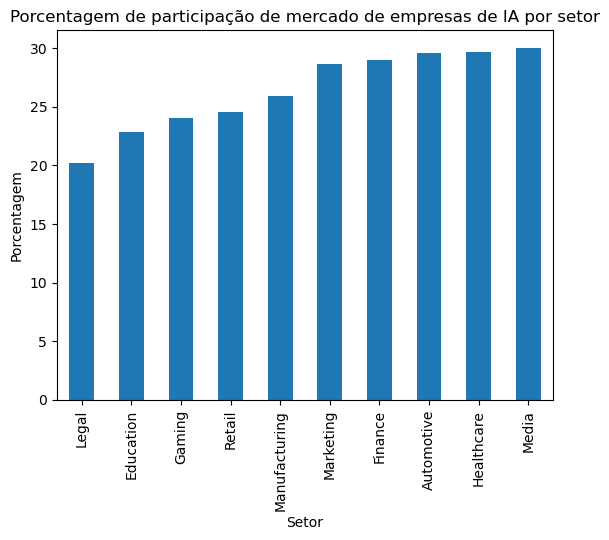

In [65]:
# Ordenando os valores de forma decrescente
df_5 = df.groupby('Industry')['Market Share of AI Companies (%)'].mean().sort_values(ascending=True)

# Gráfico de barras
df_5.plot(kind='bar')
plt.title('Porcentagem de participação de mercado de empresas de IA por setor')
plt.ylabel('Porcentagem')
plt.xlabel('Setor')
plt.show()

## Evolução do uso de IA por setor (2020-2025): Há uma tendência?

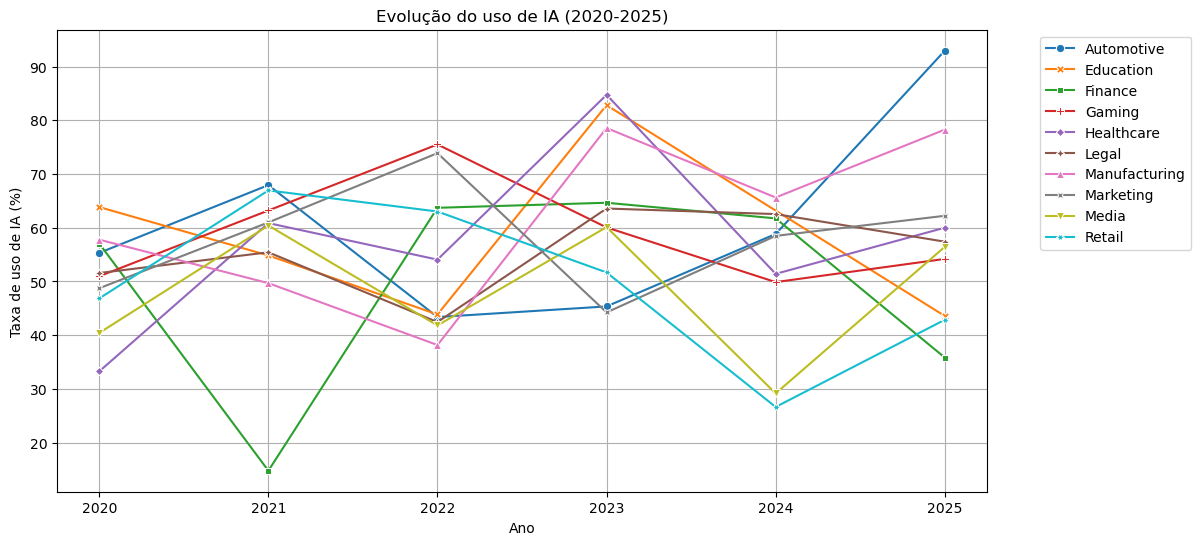

In [66]:
# Média de uso de IA por setores 
df_avg = df.groupby(['Industry', 'Year'])['AI Adoption Rate (%)'].mean().reset_index()

# Plotando a evolução do uso de IA
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_avg, 
    x='Year', 
    y='AI Adoption Rate (%)',  
    hue='Industry', 
    style='Industry', 
    markers=True, 
    dashes=False
)
plt.title("Evolução do uso de IA (2020-2025)")
plt.xlabel('Ano')
plt.ylabel("Taxa de uso de IA (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# Modelagem e predição 

Criar dicionário com os modelos de predição

In [67]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor()
}

Definir grids de hiperparâmetros por modelo

In [68]:
param_distributions = {
    "LinearRegression": {},
    "Ridge": {
        "regressor__alpha": np.logspace(-3, 3, 10)
    },
    "Lasso": {
        "regressor__alpha": np.logspace(-3, 3, 10)
    },
    "DecisionTree": {
        "regressor__max_depth": [None, 5, 10, 20],
        "regressor__min_samples_split": [2, 5, 10]
    },
    "RandomForest": {
        "regressor__n_estimators": [50, 100, 200],
        "regressor__max_depth": [None, 10, 20],
        "regressor__min_samples_split": [2, 5]
    }
}


Definir colunas alvo

In [69]:
target_columns = ["Job Loss Due to AI (%)", "Revenue Increase Due to AI (%)", "Consumer Trust in AI (%)"]
all_results = {}

Treinar os modelos

In [70]:
%%time

for target in target_columns:
    X = df.drop(columns=[target])
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

    # identificar colunas categóricas e numéricas
    categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
    numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

    # criar preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", StandardScaler(), numeric_features)
        ],
        remainder="passthrough"
    )

    rmse_results = {}

    for name, model in models.items():
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("regressor", model)
        ])

        if param_distributions.get(name):
            search = RandomizedSearchCV(
                pipeline,
                param_distributions=param_distributions[name],
                n_iter=10,
                cv=3,
                scoring="neg_mean_squared_error",
                random_state=42
            )
            search.fit(X_train, y_train)
            best_model = search.best_estimator_
        else:
            best_model = pipeline.fit(X_train, y_train)

        preds = best_model.predict(X_test)
        mse = mean_squared_error(y_test, preds)
        rmse = sqrt(mse)
        rmse_results[name] = rmse

    all_results[target] = rmse_results

C:\Users\marcelo.fridschtein\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:658: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 234.1544336394145, tolerance: 2.127444864150944
  model = cd_fast.sparse_enet_coordinate_descent(


CPU times: total: 32.3 s
Wall time: 33.4 s


Transformar resultados em DataFrame e exibir

In [71]:
all_results_df = pd.DataFrame(all_results)
print(all_results_df)

                  Job Loss Due to AI (%)  Revenue Increase Due to AI (%)  \
LinearRegression               15.233988                       27.497416   
Ridge                          13.580350                       24.786820   
Lasso                          13.617425                       24.846309   
DecisionTree                   16.503161                       27.044681   
RandomForest                   13.845579                       25.735862   

                  Consumer Trust in AI (%)  
LinearRegression                 20.554107  
Ridge                            16.625444  
Lasso                            16.599001  
DecisionTree                     20.979453  
RandomForest                     18.042363  


Montagem de gráficos:

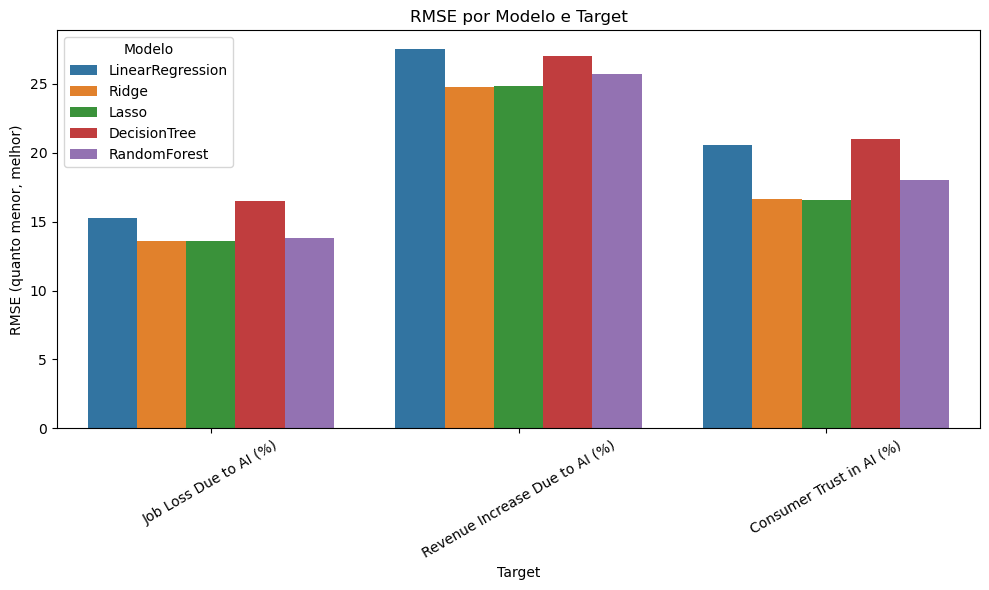

In [72]:
# Reorganizar o DataFrame para formato "long" (necessário para seaborn)
df_melted = all_results_df.reset_index().melt(id_vars="index", var_name="Target", value_name="RMSE")
df_melted.rename(columns={"index": "Model"}, inplace=True)

# Gráfico para mostrar desempenho dos modelos
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x="Target", y="RMSE", hue="Model")
plt.title("RMSE por Modelo e Target")
plt.ylabel("RMSE (quanto menor, melhor)")
plt.xticks(rotation=30)
plt.legend(title="Modelo")
plt.tight_layout()
plt.show()

# TODO
#para quem estiver revisando isso, acho legal tentar implementar um cross validation e talvez um feature importance
#mas aí fica do seu critério mesmo
#e tmb, fique à vontade para mudar as coisas ou tentar otimizar o código
#pq não faço a minima ideia de como diminuir esse tempo que demora para o código rodar